In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import glob

files = glob.glob("/content/*.csv")
files

['/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv']

In [4]:
df = pd.read_csv(files[0])

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
df.shape

(301, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.nunique()

,0
Car_Name,98
Year,16
Selling_Price,156
Present_Price,147
Kms_Driven,206
Fuel_Type,3
Seller_Type,2
Transmission,2
Owner,3


In [10]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


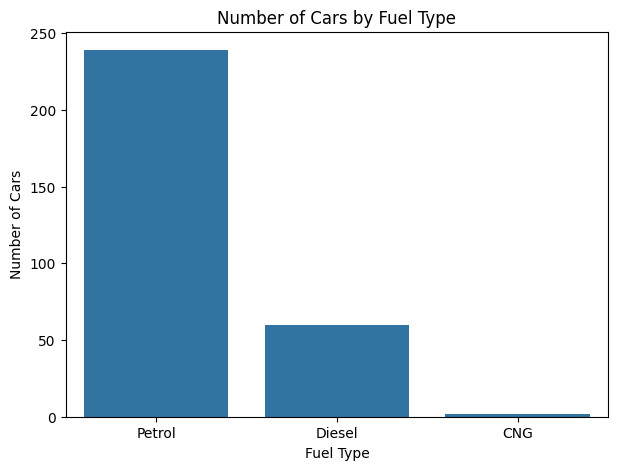

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Fuel_Type')

plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')

plt.show()

In [12]:
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


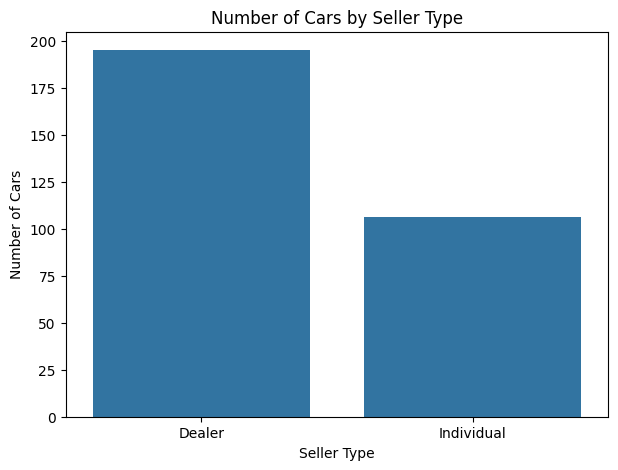

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Seller_Type')

plt.title('Number of Cars by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Number of Cars')

plt.show()

In [14]:
df['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


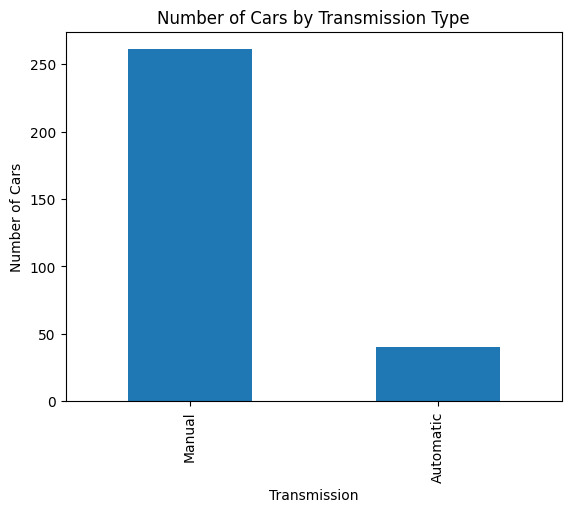

In [15]:
df['Transmission'].value_counts().plot(kind='bar')

plt.title('Number of Cars by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Number of Cars')

plt.show()

In [16]:
df['Owner'].value_counts()

,count
Owner,
0,290
1,10
3,1


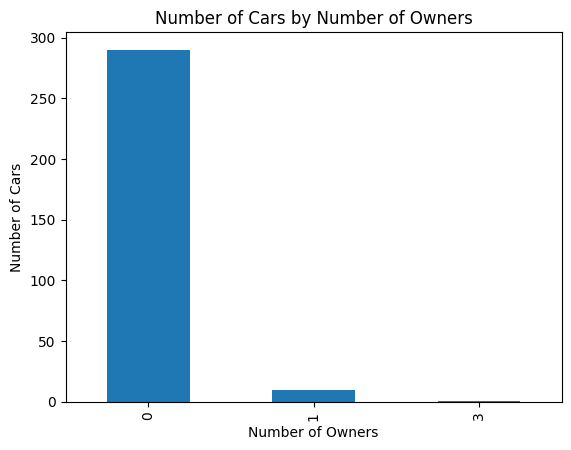

In [17]:
df['Owner'].value_counts().plot(kind='bar')

plt.title('Number of Cars by Number of Owners')
plt.xlabel('Number of Owners')
plt.ylabel('Number of Cars')

plt.show()

In [18]:
df.groupby('Year')['Selling_Price'].mean()

,Selling_Price
Year,
2003,1.300000
2004,1.500000
2005,2.487500
2006,1.437500
2007,0.160000
2008,1.002857
2009,2.816667
2010,5.262667
2011,2.375263


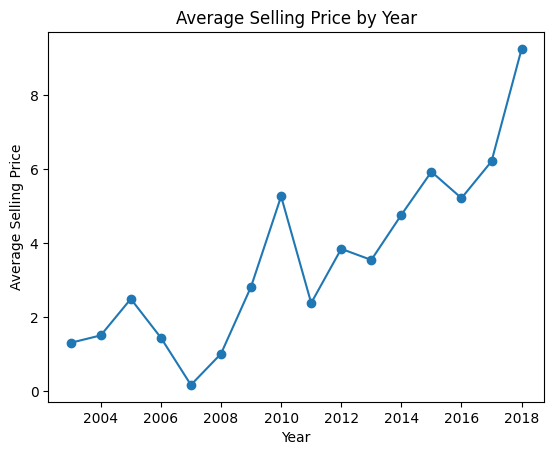

In [19]:
df.groupby('Year')['Selling_Price'].mean().plot(kind='line', marker='o')

plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')

plt.show()

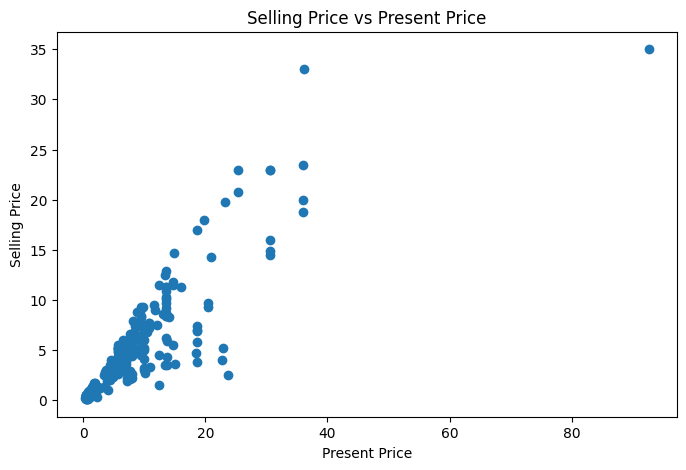

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df['Present_Price'], df['Selling_Price'])

plt.title('Selling Price vs Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')

plt.show()

In [21]:
df[['Present_Price', 'Selling_Price', 'Kms_Driven', 'Year']].corr()

,Present_Price,Selling_Price,Kms_Driven,Year
Present_Price,1.000000,0.878983,0.203647,-0.047584
Selling_Price,0.878983,1.000000,0.029187,0.236141
Kms_Driven,0.203647,0.029187,1.000000,-0.524342
Year,-0.047584,0.236141,-0.524342,1.000000


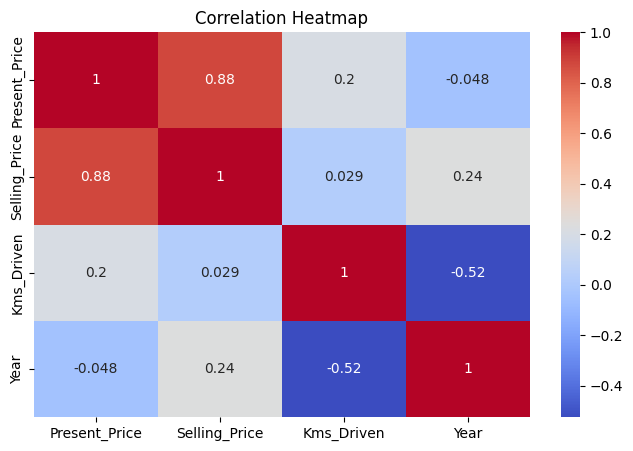

In [22]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Present_Price', 'Selling_Price', 'Kms_Driven', 'Year']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [23]:
df.sort_values('Selling_Price', ascending=False)[
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price']
].head(10)

,Car_Name,Year,Selling_Price,Present_Price
86,land cruiser,2010,35.00,92.60
64,fortuner,2017,33.00,36.23
63,fortuner,2015,23.50,35.96
51,fortuner,2015,23.00,30.61
93,fortuner,2015,23.00,30.61
82,innova,2017,23.00,25.39
96,innova,2016,20.75,25.39
59,fortuner,2014,19.99,35.96
66,innova,2017,19.75,23.15
62,fortuner,2014,18.75,35.96


In [24]:
df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)

,Selling_Price
Fuel_Type,
Diesel,10.278500
Petrol,3.264184
CNG,3.100000


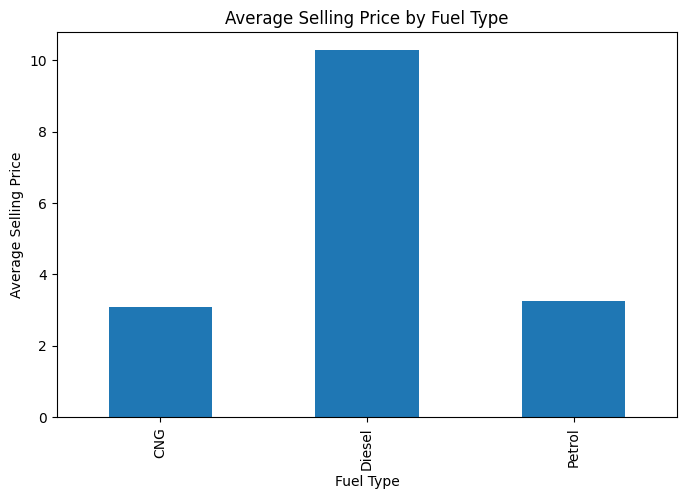

In [25]:
plt.figure(figsize=(8,5))

df.groupby('Fuel_Type')['Selling_Price'].mean().plot(kind='bar')

plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')

plt.show()

In [26]:
df.groupby('Seller_Type')['Selling_Price'].mean().sort_values(ascending=False)

,Selling_Price
Seller_Type,
Dealer,6.721692
Individual,0.870943


In [27]:
df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)

,Selling_Price
Transmission,
Automatic,9.420000
Manual,3.931992


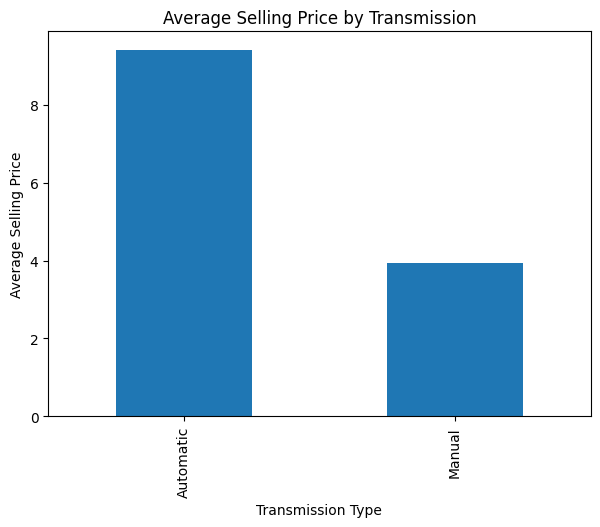

In [28]:
plt.figure(figsize=(7,5))

df.groupby('Transmission')['Selling_Price'].mean().plot(kind='bar')

plt.title('Average Selling Price by Transmission')
plt.xlabel('Transmission Type')
plt.ylabel('Average Selling Price')

plt.show()

In [29]:
df.groupby('Transmission').size()

,0
Transmission,
Automatic,40
Manual,261


In [30]:
df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)

,Selling_Price
Fuel_Type,
Diesel,10.278500
Petrol,3.264184
CNG,3.100000


In [31]:
print("CAR MARKET TRENDS ANALYSIS - KEY INSIGHTS")
print("------------------------------------------")

print("1. Selling Price has a strong relationship with Present Price.")
print("2. Dealer cars have a higher average selling price than Individual cars.")
print("3. Automatic cars have a higher average selling price than Manual cars.")
print("4. Diesel cars have the highest average selling price among fuel types.")
print("5. Higher mileage generally affects the selling price negatively.")

CAR MARKET TRENDS ANALYSIS - KEY INSIGHTS
------------------------------------------
1. Selling Price has a strong relationship with Present Price.
2. Dealer cars have a higher average selling price than Individual cars.
3. Automatic cars have a higher average selling price than Manual cars.
4. Diesel cars have the highest average selling price among fuel types.
5. Higher mileage generally affects the selling price negatively.


In [32]:
print("CAR MARKET TRENDS ANALYSIS - FINAL CONCLUSION")
print("--------------------------------------------")

print("• Selling price is strongly influenced by present price.")
print("• Dealer cars generally have higher selling prices than individual cars.")
print("• Automatic cars have a higher average selling price than manual cars.")
print("• Diesel cars have the highest average selling price among fuel types.")
print("• Higher kilometers driven generally reduces the selling price.")
print("• Overall, car age, mileage, fuel type, transmission and seller type")
print("  play an important role in determining the resale value of cars.")

print("\nProject Completed Successfully!")

CAR MARKET TRENDS ANALYSIS - FINAL CONCLUSION
--------------------------------------------
• Selling price is strongly influenced by present price.
• Dealer cars generally have higher selling prices than individual cars.
• Automatic cars have a higher average selling price than manual cars.
• Diesel cars have the highest average selling price among fuel types.
• Higher kilometers driven generally reduces the selling price.
• Overall, car age, mileage, fuel type, transmission and seller type
  play an important role in determining the resale value of cars.

Project Completed Successfully!
